# **Image Super Resolution — SRCNN (Local PC / RTX 5060 Ti)**

Converted from Google Colab. All `/content/` and Google Drive paths replaced with local paths.

**Expected folder structure (inside your project root):**
```
~/sr_project/
├── HR_256/          ← high-resolution images  (0000.png … 0109.png)
├── LR_x4/           ← low-resolution images   (0000.png … 0109.png)
├── srcnn_compare/   ← created automatically
└── best_srcnn_x4.pth← saved automatically
```

## **Cell 1 — Imports & Device**

In [13]:
import os, random, math
os.environ['PYTORCH_CUDA_ALLOC_CONF'] = 'expandable_segments:True'

from pathlib import Path
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
import torchvision.transforms.functional as TF
from PIL import Image
import matplotlib.pyplot as plt

# ── Project root: change this if your data is elsewhere ──────────────────────
PROJECT_ROOT = Path.home() / 'sr_project'

HR_DIR = PROJECT_ROOT / 'HR_256'
LR_DIR = PROJECT_ROOT / 'LR_x4'
OUT_DIR = PROJECT_ROOT / 'srcnn_compare'
CKPT    = PROJECT_ROOT / 'best_srcnn_x4.pth'

OUT_DIR.mkdir(parents=True, exist_ok=True)

assert HR_DIR.exists(), f'HR_256 folder not found at {HR_DIR}'
assert LR_DIR.exists(), f'LR_x4 folder not found at {LR_DIR}'

print('HR_DIR :', HR_DIR)
print('LR_DIR :', LR_DIR)
print('OUT_DIR:', OUT_DIR)
print('CKPT   :', CKPT)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'\nDevice : {device}')
if torch.cuda.is_available():
    print(f'GPU    : {torch.cuda.get_device_name(0)}')
    print(f'VRAM   : {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB')

HR_DIR : /home/rokib/sr_project/HR_256
LR_DIR : /home/rokib/sr_project/LR_x4
OUT_DIR: /home/rokib/sr_project/srcnn_compare
CKPT   : /home/rokib/sr_project/best_srcnn_x4.pth

Device : cuda
GPU    : NVIDIA GeForce RTX 5060 Ti
VRAM   : 17.1 GB


## **Cell 2 — Define Train / Val / Test IDs**

In [14]:
def make_ids(start, end):
    return [f'{i:04d}' for i in range(start, end + 1)]

train_ids = make_ids(0, 89)    # 90 images for training
val_ids   = make_ids(90, 99)   # 10 images for validation
test_ids  = make_ids(100, 109) # 10 images for final test

print(f'Train : {len(train_ids)} images  ({train_ids[0]} … {train_ids[-1]})')
print(f'Val   : {len(val_ids)}  images  ({val_ids[0]} … {val_ids[-1]})')
print(f'Test  : {len(test_ids)} images  ({test_ids[0]} … {test_ids[-1]})')

Train : 90 images  (0000 … 0089)
Val   : 10  images  (0090 … 0099)
Test  : 10 images  (0100 … 0109)


## **Cell 3 — Dataset Classes**

In [15]:
def find_img(folder: Path, id_: str) -> Path:
    """Find image file by id, supporting .png / .jpg / .jpeg."""
    for ext in ['.png', '.jpg', '.jpeg']:
        p = folder / f'{id_}{ext}'
        if p.exists():
            return p
    raise FileNotFoundError(f'No image for id={id_} in {folder}')


class SRDataset(Dataset):
    """Patch-based training dataset with augmentation."""
    def __init__(self, lr_dir, hr_dir, ids, scale=4, patch_size=32, augment=True):
        self.lr_dir     = Path(lr_dir)
        self.hr_dir     = Path(hr_dir)
        self.ids        = ids
        self.scale      = scale
        self.patch_size = patch_size
        self.augment    = augment

    def __len__(self):
        return len(self.ids)

    def __getitem__(self, idx):
        id_ = self.ids[idx]
        lr  = TF.to_tensor(Image.open(find_img(self.lr_dir, id_)).convert('RGB'))
        hr  = TF.to_tensor(Image.open(find_img(self.hr_dir, id_)).convert('RGB'))

        _, h, w = lr.shape
        p, s    = self.patch_size, self.scale
        top     = random.randint(0, h - p)
        left    = random.randint(0, w - p)

        lr_patch = lr[:, top:top+p,       left:left+p]
        hr_patch = hr[:, top*s:(top+p)*s, left*s:(left+p)*s]

        if self.augment:
            if random.random() < 0.5:
                lr_patch = TF.hflip(lr_patch); hr_patch = TF.hflip(hr_patch)
            if random.random() < 0.5:
                lr_patch = TF.vflip(lr_patch); hr_patch = TF.vflip(hr_patch)
            k = random.randint(0, 3)
            if k:
                lr_patch = torch.rot90(lr_patch, k, [1, 2])
                hr_patch = torch.rot90(hr_patch, k, [1, 2])

        return lr_patch, hr_patch


class SRImageDataset(Dataset):
    """Full-image dataset for validation / test."""
    def __init__(self, lr_dir, hr_dir, ids):
        self.lr_dir = Path(lr_dir)
        self.hr_dir = Path(hr_dir)
        self.ids    = ids

    def __len__(self):
        return len(self.ids)

    def __getitem__(self, idx):
        id_ = self.ids[idx]
        lr  = TF.to_tensor(Image.open(find_img(self.lr_dir, id_)).convert('RGB'))
        hr  = TF.to_tensor(Image.open(find_img(self.hr_dir, id_)).convert('RGB'))
        return lr, hr, id_


print('Dataset classes defined.')

Dataset classes defined.


## **Cell 4 — DataLoaders**

In [16]:
SCALE      = 4
PATCH      = 32
BATCH      = 16

train_ds     = SRDataset(LR_DIR, HR_DIR, train_ids, scale=SCALE, patch_size=PATCH, augment=True)
train_loader = DataLoader(train_ds, batch_size=BATCH, shuffle=True,
                          num_workers=4, pin_memory=True, persistent_workers=True)

val_ds       = SRImageDataset(LR_DIR, HR_DIR, val_ids)
val_loader   = DataLoader(val_ds, batch_size=1, shuffle=False, num_workers=2)

test_ds      = SRImageDataset(LR_DIR, HR_DIR, test_ids)
test_loader  = DataLoader(test_ds, batch_size=1, shuffle=False, num_workers=2)

print(f'Train batches : {len(train_loader)}  (batch_size={BATCH})')
print(f'Val   images  : {len(val_ds)}')
print(f'Test  images  : {len(test_ds)}')

Train batches : 6  (batch_size=16)
Val   images  : 10
Test  images  : 10


## **Cell 5 — SRCNN Model**

In [17]:
class SRCNN(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Conv2d(3, 64, 9, padding=4),
            nn.ReLU(True),
            nn.Conv2d(64, 32, 5, padding=2),
            nn.ReLU(True),
            nn.Conv2d(32, 3,  5, padding=2)
        )
        for m in self.modules():
            if isinstance(m, nn.Conv2d):
                nn.init.kaiming_normal_(m.weight)
                if m.bias is not None:
                    nn.init.zeros_(m.bias)

    def forward(self, x):
        return self.net(x)


model = SRCNN().to(device)
params = sum(p.numel() for p in model.parameters())
print(f'SRCNN ready — {params:,} parameters  on {device}')

SRCNN ready — 69,251 parameters  on cuda


## **Cell 6 — Helper Functions**

In [18]:
def psnr(sr, hr):
    mse = F.mse_loss(sr.clamp(0,1), hr.clamp(0,1))
    return 10 * torch.log10(1.0 / mse)


def bicubic_up(x, scale=4):
    return F.interpolate(x, scale_factor=scale,
                         mode='bicubic', align_corners=False).clamp(0, 1)


def t2pil(x):
    return TF.to_pil_image(x.squeeze(0).cpu().clamp(0, 1))


def validate_psnr(loader):
    model.eval()
    vals = []
    with torch.no_grad():
        for lr_img, hr_img, _ in loader:
            lr_img = lr_img.to(device)
            hr_img = hr_img.to(device)
            lr_up  = bicubic_up(lr_img, SCALE)
            sr     = model(lr_up).clamp(0, 1)
            vals.append(psnr(sr, hr_img).item())
    return float(np.mean(vals))


print('Helper functions defined.')

Helper functions defined.


## **Cell 7 — Training Loop**

In [19]:
EPOCHS    = 100
criterion = nn.MSELoss()
optimizer = optim.Adam(model.parameters(), lr=1e-4)
scheduler = optim.lr_scheduler.StepLR(optimizer, step_size=30, gamma=0.5)
scaler    = torch.amp.GradScaler('cuda')   # mixed precision

best_val  = -1.0
history   = {'loss': [], 'val_psnr': []}

print('Starting training...')
print(f'Epochs: {EPOCHS}  |  Batch: {BATCH}  |  Patch: {PATCH}×{PATCH}  |  Scale: ×{SCALE}')
print('-' * 60)

for epoch in range(1, EPOCHS + 1):
    model.train()
    losses = []

    for lr_patch, hr_patch in train_loader:
        lr_patch = lr_patch.to(device, non_blocking=True)
        hr_patch = hr_patch.to(device, non_blocking=True)

        # Bicubic upsample LR patch to HR size before feeding SRCNN
        lr_up = bicubic_up(lr_patch, SCALE)

        with torch.amp.autocast('cuda'):
            sr   = model(lr_up)
            loss = criterion(sr, hr_patch)

        optimizer.zero_grad()
        scaler.scale(loss).backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        scaler.step(optimizer)
        scaler.update()

        losses.append(loss.item())

    scheduler.step()

    val_ps = validate_psnr(val_loader)
    avg_loss = float(np.mean(losses))
    history['loss'].append(avg_loss)
    history['val_psnr'].append(val_ps)

    tag = ''
    if val_ps > best_val:
        best_val = val_ps
        torch.save(model.state_dict(), CKPT)
        tag = '  ✅ best saved'

    print(f'Epoch {epoch:03d} | Loss: {avg_loss:.6f} | Val PSNR: {val_ps:.2f} dB{tag}')

print(f'\nTraining complete. Best Val PSNR: {best_val:.2f} dB')
print(f'Checkpoint saved to: {CKPT}')

Starting training...
Epochs: 100  |  Batch: 16  |  Patch: 32×32  |  Scale: ×4
------------------------------------------------------------
Epoch 001 | Loss: 0.266031 | Val PSNR: 11.16 dB  ✅ best saved
Epoch 002 | Loss: 0.066213 | Val PSNR: 14.37 dB  ✅ best saved
Epoch 003 | Loss: 0.038905 | Val PSNR: 16.33 dB  ✅ best saved
Epoch 004 | Loss: 0.030860 | Val PSNR: 17.10 dB  ✅ best saved
Epoch 005 | Loss: 0.025475 | Val PSNR: 17.30 dB  ✅ best saved
Epoch 006 | Loss: 0.021760 | Val PSNR: 17.94 dB  ✅ best saved
Epoch 007 | Loss: 0.018636 | Val PSNR: 18.67 dB  ✅ best saved
Epoch 008 | Loss: 0.015943 | Val PSNR: 19.27 dB  ✅ best saved
Epoch 009 | Loss: 0.014274 | Val PSNR: 19.78 dB  ✅ best saved
Epoch 010 | Loss: 0.012842 | Val PSNR: 20.16 dB  ✅ best saved
Epoch 011 | Loss: 0.011430 | Val PSNR: 20.37 dB  ✅ best saved
Epoch 012 | Loss: 0.010346 | Val PSNR: 20.53 dB  ✅ best saved
Epoch 013 | Loss: 0.009899 | Val PSNR: 20.62 dB  ✅ best saved
Epoch 014 | Loss: 0.009631 | Val PSNR: 20.83 dB  ✅ best

## **Cell 8 — Training History Plot**

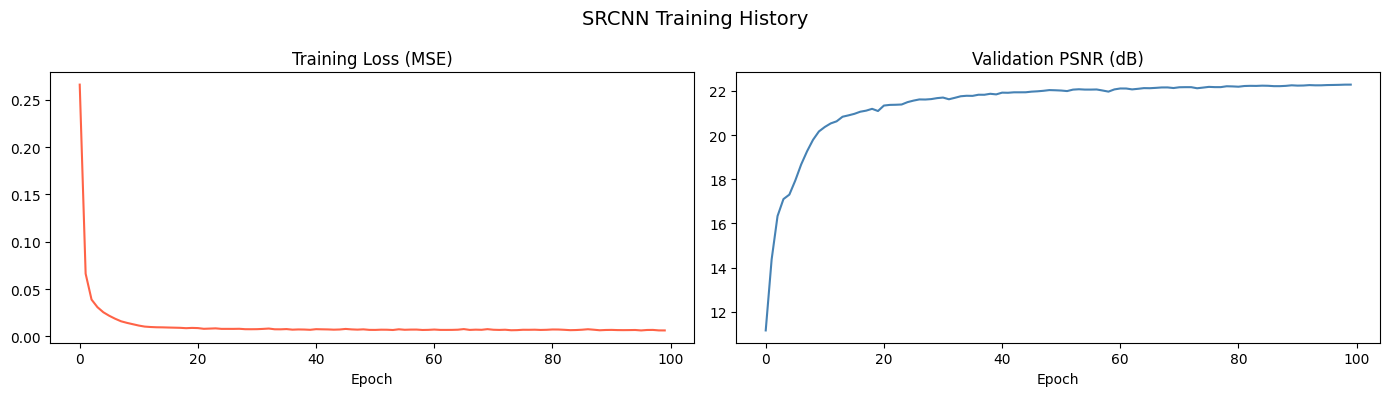

Saved → /home/rokib/sr_project/training_history.png


In [20]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 4))

ax1.plot(history['loss'], color='tomato')
ax1.set_title('Training Loss (MSE)'); ax1.set_xlabel('Epoch')

ax2.plot(history['val_psnr'], color='steelblue')
ax2.set_title('Validation PSNR (dB)'); ax2.set_xlabel('Epoch')

plt.suptitle('SRCNN Training History', fontsize=14)
plt.tight_layout()
save_path = PROJECT_ROOT / 'training_history.png'
plt.savefig(save_path, dpi=150)
plt.show()
print(f'Saved → {save_path}')

## **Cell 9 — Evaluate on Test Set**

In [21]:
model.load_state_dict(torch.load(CKPT, map_location=device, weights_only=True))
model.eval()

bic_psnrs, srcnn_psnrs = [], []

with torch.no_grad():
    for lr_img, hr_img, id_ in test_loader:
        lr_img = lr_img.to(device)
        hr_img = hr_img.to(device)

        bic = bicubic_up(lr_img, SCALE)
        sr  = model(bic).clamp(0, 1)

        bp = psnr(bic, hr_img).item()
        sp = psnr(sr,  hr_img).item()
        bic_psnrs.append(bp)
        srcnn_psnrs.append(sp)
        print(f'ID {id_[0]}  Bicubic: {bp:.2f} dB  SRCNN: {sp:.2f} dB  ({sp-bp:+.2f} dB)')

print(f'\nAvg Bicubic PSNR : {np.mean(bic_psnrs):.2f} dB')
print(f'Avg SRCNN   PSNR : {np.mean(srcnn_psnrs):.2f} dB')
print(f'Average gain     : {np.mean(srcnn_psnrs) - np.mean(bic_psnrs):+.2f} dB')

ID 0100  Bicubic: 24.09 dB  SRCNN: 21.75 dB  (-2.34 dB)
ID 0101  Bicubic: 26.39 dB  SRCNN: 26.69 dB  (+0.30 dB)
ID 0102  Bicubic: 18.25 dB  SRCNN: 18.98 dB  (+0.73 dB)
ID 0103  Bicubic: 23.20 dB  SRCNN: 23.71 dB  (+0.51 dB)
ID 0104  Bicubic: 21.69 dB  SRCNN: 22.16 dB  (+0.47 dB)
ID 0105  Bicubic: 22.00 dB  SRCNN: 22.63 dB  (+0.63 dB)
ID 0106  Bicubic: 26.69 dB  SRCNN: 27.02 dB  (+0.32 dB)
ID 0107  Bicubic: 21.96 dB  SRCNN: 23.15 dB  (+1.19 dB)
ID 0108  Bicubic: 22.52 dB  SRCNN: 22.82 dB  (+0.30 dB)
ID 0109  Bicubic: 23.72 dB  SRCNN: 24.78 dB  (+1.05 dB)

Avg Bicubic PSNR : 23.05 dB
Avg SRCNN   PSNR : 23.37 dB
Average gain     : +0.32 dB


## **Cell 10 — Visual Comparison (LR / Bicubic / SRCNN / HR)**

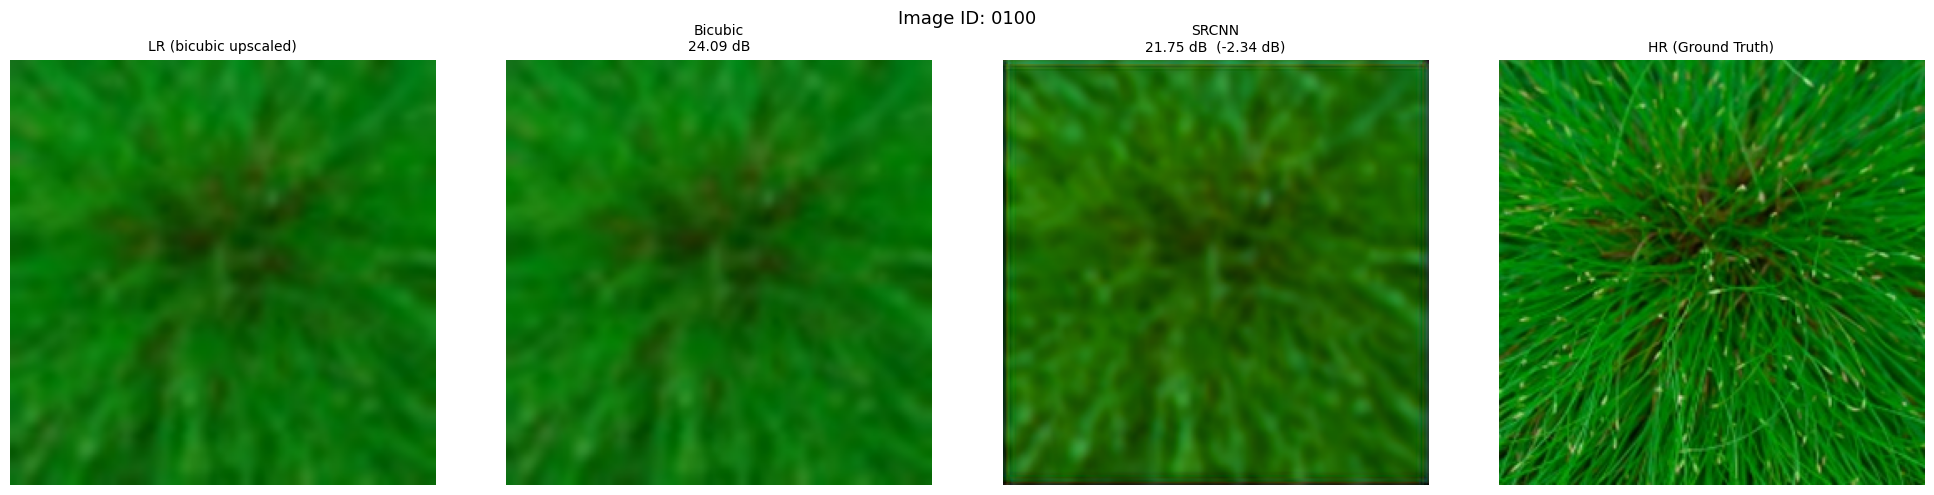

Saved → /home/rokib/sr_project/srcnn_compare/0100_COMPARE.png


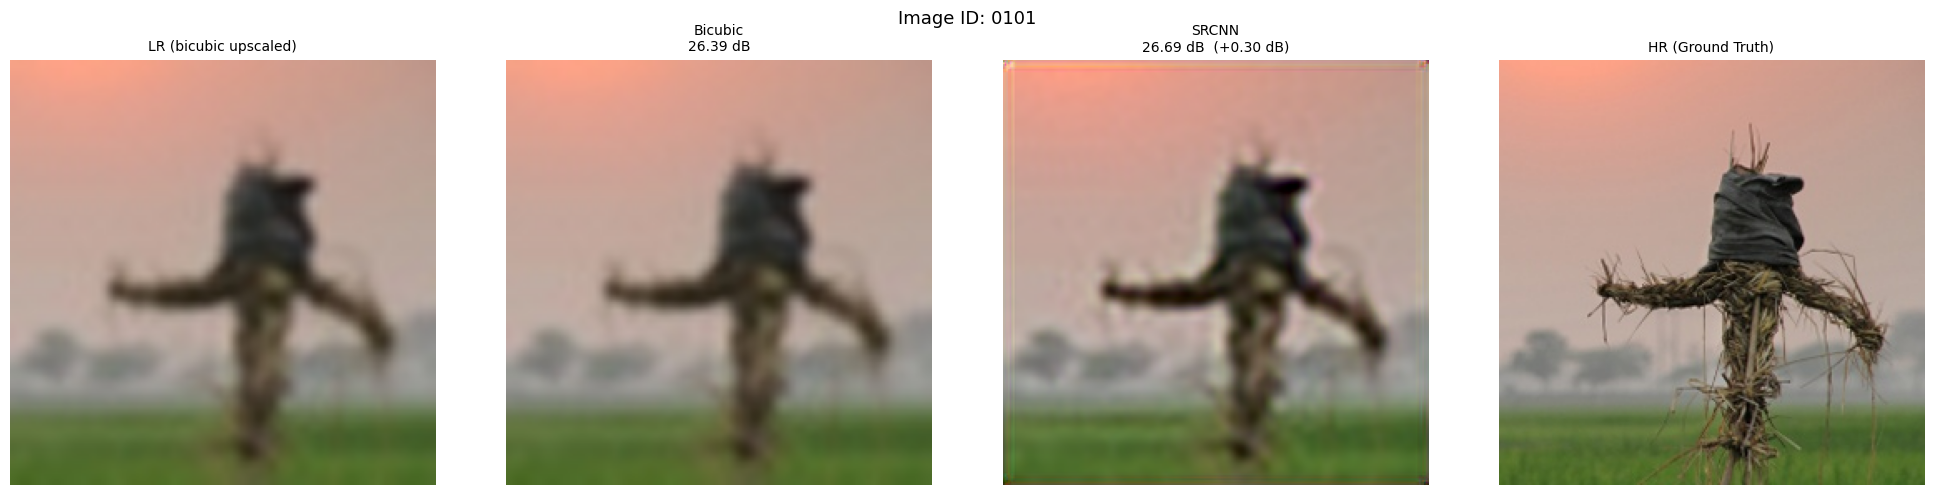

Saved → /home/rokib/sr_project/srcnn_compare/0101_COMPARE.png


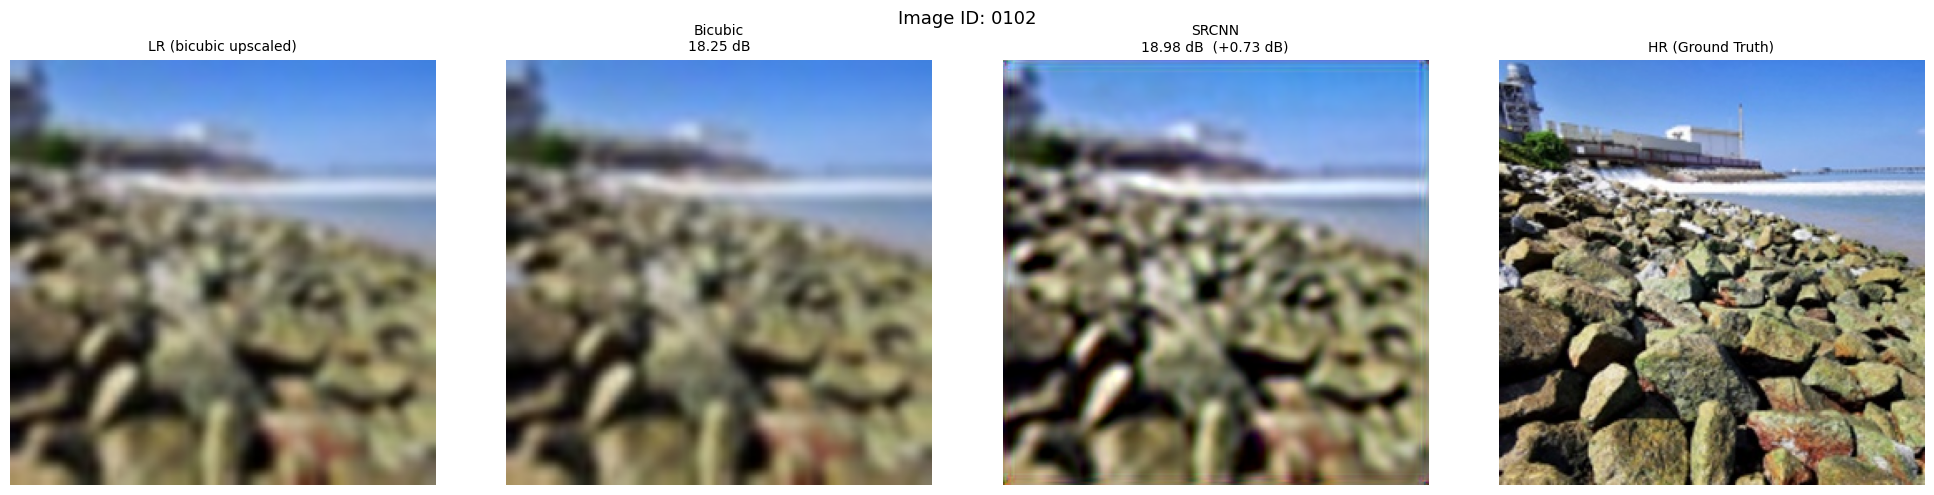

Saved → /home/rokib/sr_project/srcnn_compare/0102_COMPARE.png


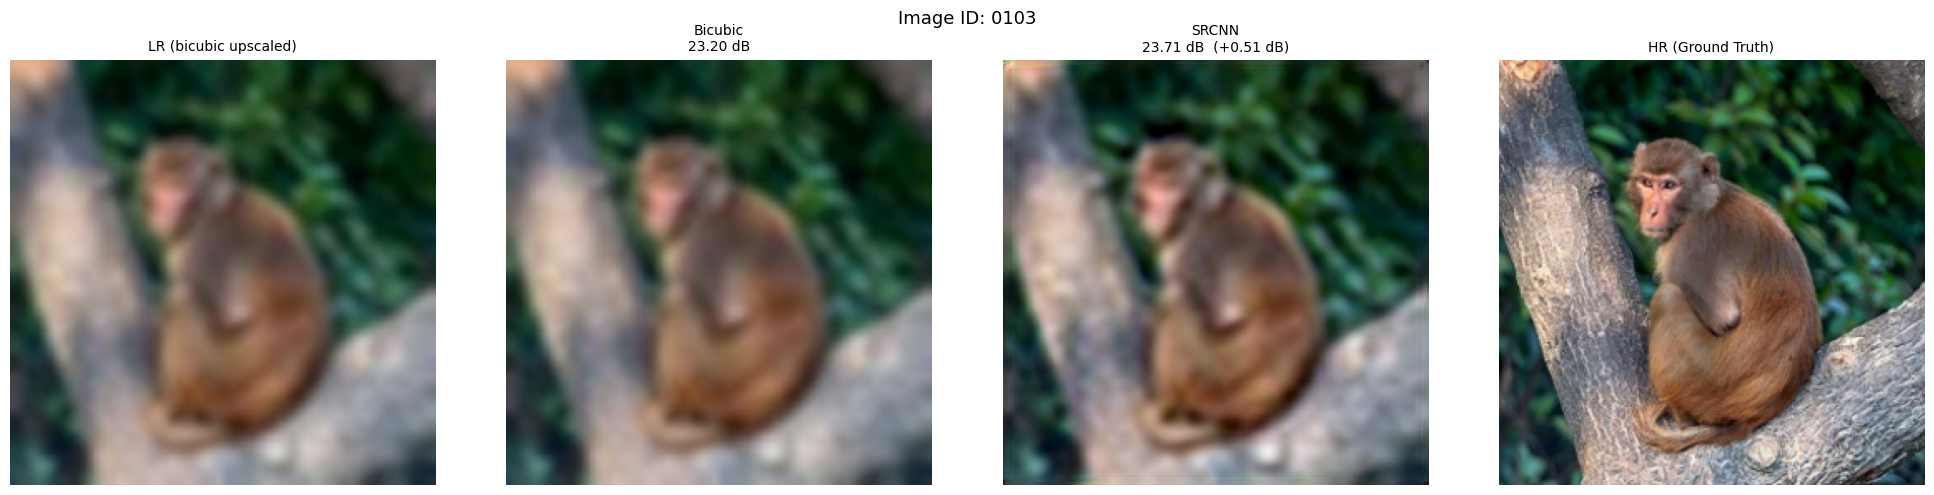

Saved → /home/rokib/sr_project/srcnn_compare/0103_COMPARE.png


In [22]:
def save_compare(id_: str):
    lr = TF.to_tensor(Image.open(find_img(LR_DIR, id_)).convert('RGB')).unsqueeze(0).to(device)
    hr = TF.to_tensor(Image.open(find_img(HR_DIR, id_)).convert('RGB')).unsqueeze(0).to(device)

    with torch.no_grad():
        bic = bicubic_up(lr, SCALE)
        sr  = model(bic).clamp(0, 1)

    p_bic = psnr(bic, hr).item()
    p_sr  = psnr(sr,  hr).item()

    fig, axes = plt.subplots(1, 4, figsize=(20, 5))
    for ax, img, title in zip(
        axes,
        [bic, bic, sr, hr],
        ['LR (bicubic upscaled)', f'Bicubic\n{p_bic:.2f} dB',
         f'SRCNN\n{p_sr:.2f} dB  ({p_sr-p_bic:+.2f} dB)', 'HR (Ground Truth)']
    ):
        ax.imshow(t2pil(img)); ax.set_title(title, fontsize=10); ax.axis('off')

    plt.suptitle(f'Image ID: {id_}', fontsize=13)
    plt.tight_layout()
    out_path = OUT_DIR / f'{id_}_COMPARE.png'
    fig.savefig(out_path, dpi=150, bbox_inches='tight')
    plt.show()
    plt.close(fig)
    print(f'Saved → {out_path}')


# Generate comparison for first 4 test images
for id_ in test_ids[:4]:
    save_compare(id_)

## **Cell 11 — Sanity Check: Verify LR/HR Size Alignment**

In [23]:
print('Checking LR / HR size alignment for test images...\n')
for id_ in test_ids[:4]:
    lr_path = find_img(LR_DIR, id_)
    hr_path = find_img(HR_DIR, id_)
    lr_img  = Image.open(lr_path)
    hr_img  = Image.open(hr_path)
    lw, lh  = lr_img.size
    hw, hh  = hr_img.size
    ok      = hw == lw * 4 and hh == lh * 4
    print(f'ID {id_}  LR: {lw}×{lh}  HR: {hw}×{hh}  scale=×4 correct: {ok}')

Checking LR / HR size alignment for test images...

ID 0100  LR: 64×64  HR: 256×256  scale=×4 correct: True
ID 0101  LR: 64×64  HR: 256×256  scale=×4 correct: True
ID 0102  LR: 64×64  HR: 256×256  scale=×4 correct: True
ID 0103  LR: 64×64  HR: 256×256  scale=×4 correct: True


## **Cell 12 — Save All Outputs as ZIP**

In [24]:
import shutil

zip_path = PROJECT_ROOT / 'srcnn_compare'
shutil.make_archive(str(zip_path), 'zip', str(OUT_DIR))
print(f'✅ Comparison images zipped → {zip_path}.zip')
print(f'✅ Model checkpoint        → {CKPT}')

✅ Comparison images zipped → /home/rokib/sr_project/srcnn_compare.zip
✅ Model checkpoint        → /home/rokib/sr_project/best_srcnn_x4.pth
